In [1]:
import torch

# you might have to install this (minicons), we dont need to use it per se, 
# but it has good functionality for sequence scoring
from minicons import scorer 

from torch import optim
from tqdm import trange, tqdm
from transformers import get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup, get_constant_schedule, set_seed
from PIL import Image

In [2]:
from transformers import set_seed
set_seed(42)


In [3]:
lm = scorer.VLMScorer("Qwen/Qwen3-VL-2B-Instruct", 
                      device="cuda", 
                      torch_dtype=torch.bfloat16, 
                      cache_dir="/mnt/dv/wid/projects3/Rogers-muri-human-ai/zstuddiford"
                    )

def chat_template(self, text, noimage=False, assistant=False):
    if noimage == False:
        context = [
            {
                "role": "user",
                "content": [{"type": "image"},{"type": "text", "text": text}],
            }
        ]
    else:
        context = [
            {
                "role": "user",
                "content": [{"type": "text", "text": text}],
            }
        ]

    if not assistant:
        context = self.tokenizer.apply_chat_template(
            context, continue_final_message=True
        )
    else:
        context = self.tokenizer.apply_chat_template(
            context, add_generation_prompt=True
        )
    return context


# Default prompt is to caption the image -- we could play around with this as well, like have it
# be something like "Answer the question", and train on wug and wugs in a QA format, tons of things
# to think about!

def train_chat_template(self, text):
    context = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": "Caption this image."},
            ]
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": text}
            ]
        }
    ]
    return self.tokenizer.apply_chat_template(context, add_generation_prompt=False).strip()

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

In [76]:
SYNTAX_PATH_BEST= "../temp_embeddings/syntax/qwen3_vl_2b_syntax.pt"

added_tokens = [" [wug]", " [wugs]"]
existing_vocab = lm.tokenizer.tokenizer.get_vocab()
tokens_to_add = [t for t in added_tokens if t not in existing_vocab]
if tokens_to_add:
    lm.tokenizer.tokenizer.add_tokens(tokens_to_add)
    old_len = lm.model.resize_token_embeddings().weight.shape[0]
    lm.model.resize_token_embeddings(old_len + len(tokens_to_add))

saved = torch.load(SYNTAX_PATH_BEST)

emb = lm.model.model.language_model.embed_tokens
emb.weight.data[saved["wug_id"]] = saved["wug_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
emb.weight.data[saved["wugs_id"]] = saved["wugs_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)

print(f"Loaded embeddings for [wug] (id={saved['wug_id']}) and [wugs] (id={saved['wugs_id']})")
print(f"  [wug]  norm: {emb.weight[saved['wug_id']].norm().item():.4f}")
print(f"  [wugs] norm: {emb.weight[saved['wugs_id']].norm().item():.4f}")

Loaded embeddings for [wug] (id=151669) and [wugs] (id=151670)
  [wug]  norm: 1.5078
  [wugs] norm: 1.5078


✓ all 31232 queries contain a novel token (wug=151669, wugs=151670)
Scoring good queries...
    scored 15616/15616
Scoring bad queries...
    scored 15616/15616

N pairs: 15616

Noun-ending (cue sentence … The wug)  (overall acc=0.516, n=3072)
  0 attractor(s): all=0.559  sg=0.609  pl=0.508  (n=768)
  1 attractor(s): all=0.491  sg=0.716  pl=0.266  (n=768)
  2 attractor(s): all=0.496  sg=0.727  pl=0.266  (n=768)
  3 attractor(s): all=0.517  sg=0.695  pl=0.339  (n=768)

Verb-ending (wug … verb)  (overall acc=0.862, n=12544)
  0 attractor(s): all=0.891  sg=0.809  pl=0.973  (n=1792)
  1 attractor(s): all=0.881  sg=0.835  pl=0.928  (n=3584)
  2 attractor(s): all=0.852  sg=0.820  pl=0.884  (n=3584)
  3 attractor(s): all=0.836  sg=0.808  pl=0.864  (n=3584)


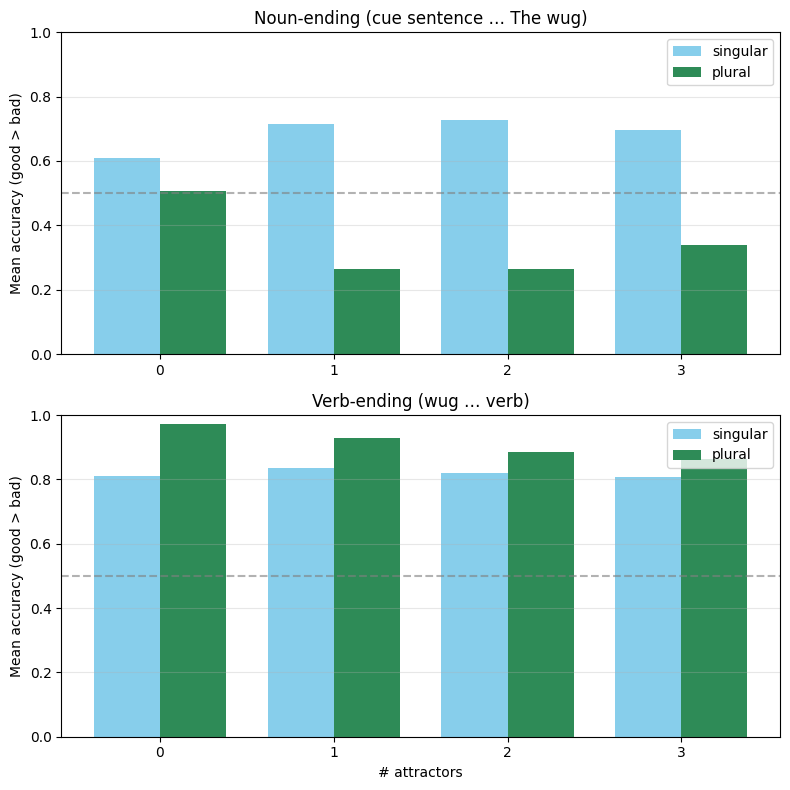

In [ ]:
import torch
import random
import matplotlib.pyplot as plt
import numpy as np

random.seed(0)

# ==========================================================
# Fillers
# ==========================================================
ADJ_FILLERS = [
    "small", "fuzzy", "curious", "quiet", "clever", "tiny", "strange", "gentle",
    "bright", "sleepy", "nervous", "calm", "round", "spotted", "shy", "bold",
    "scruffy", "slender", "plump", "wary", "restless", "timid", "lively", "drowsy",
    "skittish", "sturdy", "graceful", "clumsy", "fierce", "mellow", "jittery", "placid",
]

# Verb-ending condition: wug is subject, verb flips at end
VERB_FILLERS = [
    ("is", "are"), ("was", "were"), ("has", "have"), ("does", "do"),
    ("goes", "go"), ("seems", "seem"), ("looks", "look"), ("feels", "feel"),
    ("stays", "stay"), ("grows", "grow"), ("knows", "know"), ("comes", "come"),
    ("runs", "run"), ("jumps", "jump"), ("sleeps", "sleep"), ("eats", "eat"),
    ("walks", "walk"), ("climbs", "climb"), ("hides", "hide"), ("rests", "rest"),
    ("plays", "play"), ("waits", "wait"), ("moves", "move"), ("watches", "watch"),
    ("carries", "carry"), ("gathers", "gather"), ("scatters", "scatter"), ("glows", "glow"),
]

# ----------------------------------------------------------
# Noun-ending cue sentences: number lives ONLY here.
# Built from (singular-subject, plural-subject) pairs x intransitive verbs.
# Both the subject pronoun and the verb agreement encode number, so the cue
# is redundant and robust; nothing downstream reveals number.
# ----------------------------------------------------------
SUBJECT_PAIRS = [
    ("it", "they")

]
INTRANS_VERBS = [
    ("lies", "lie"), ("sits", "sit"), ("stands", "stand"), ("waits", "wait"),
    ("rests", "rest"), ("hides", "hide"), ("sleeps", "sleep"), ("moves", "move"),
    ("lingers", "linger"), ("wanders", "wander"), ("crouches", "crouch"),
    ("dwells", "dwell"), ("roams", "roam"), ("settles", "settle"),
    ("perches", "perch"), ("breathes", "breathe"),
]
CUE_PAIRS = [
    (f"{s_sg} {v_sg}", f"{s_pl} {v_pl}")
    for s_sg, s_pl in SUBJECT_PAIRS
    for v_sg, v_pl in INTRANS_VERBS
]  # 5 x 16 = 80 cue pairs

FILLER_NOUNS = ["house", "tree", "barn", "fence", "pond", "rock",
                "hill", "gate", "bush", "wall", "shed", "field",
                "houses", "trees", "barns", "fences", "ponds", "rocks",
                "hills", "gates", "bushes", "walls", "sheds", "fields"]
FILLER_PREPS = ["by the", "near the", "beside the", "behind the",
                "under the", "around the"]

# ==========================================================
# Knobs
# ==========================================================
MAX_ATTRACTORS  = 3
N_ATTR_SAMPLES  = 2
BATCH_SIZE      = 16
N_CUE_SAMPLES   = 12   # cue pairs sampled per (adj, level); keeps counts sane vs 80 total

# ==========================================================
# Attractor chain for the VERB-ending frame (inline PPs, no commas)
# ==========================================================
def make_chain(n):
    if n == 0:
        return ""
    prep = random.choice(FILLER_PREPS)
    noun = random.choice(FILLER_NOUNS)
    return f" {prep} {noun}" + make_chain(n - 1)

# ==========================================================
# Attractor chain for the NOUN-ending frame (comma-separated PP fragments)
#   -> " By the tree, Near the house,"
# ==========================================================
def make_sent_chain(n):
    if n == 0:
        return ""
    prep = random.choice(FILLER_PREPS)
    noun = random.choice(FILLER_NOUNS)
    frag = prep[0].upper() + prep[1:]          # capitalize: "By the"
    return f" {frag} {noun}," + make_sent_chain(n - 1)

# ==========================================================
# Generate good/bad pairs + parallel metadata
#   meta entry: (n_attractors, number, condition)
# ==========================================================
goods, bads = [], []
meta = []

# ---- verb-ending: wug is subject (front), verb flips at end ----
for n_attr in range(MAX_ATTRACTORS + 1):
    n_samples = 1 if n_attr == 0 else N_ATTR_SAMPLES
    for adj in ADJ_FILLERS:
        for v_sg, v_pl in VERB_FILLERS:
            for _ in range(n_samples):
                chain = make_chain(n_attr)
                goods.append(f"The {adj} [wug]{chain} {v_sg}.")
                bads .append(f"The {adj} [wug]{chain} {v_pl}.")
                meta.append((n_attr, "sg", "verb_end"))
                goods.append(f"The {adj} [wugs]{chain} {v_pl}.")
                bads .append(f"The {adj} [wugs]{chain} {v_sg}.")
                meta.append((n_attr, "pl", "verb_end"))

# ---- noun-ending: cue sentence + attractor fragments + "The {adj} wug" ----
#   sg: "There it lies, <attractors> The fuzzy [wug]"   good=[wug]
#   pl: "There they lie, <attractors> The fuzzy [wugs]" good=[wugs]
for n_attr in range(MAX_ATTRACTORS + 1):
    for adj in ADJ_FILLERS:
        cues = random.sample(CUE_PAIRS, N_CUE_SAMPLES)
        for cue_sg, cue_pl in cues:
            chain = make_sent_chain(n_attr)
            goods.append(f"There {cue_sg}:{chain} The {adj} [wug]")
            bads .append(f"There {cue_sg}:{chain} The {adj} [wugs]")
            meta.append((n_attr, "sg", "noun_end"))
            chain2 = make_sent_chain(n_attr)
            goods.append(f"There {cue_pl}:{chain2} The {adj} [wugs]")
            bads .append(f"There {cue_pl}:{chain2} The {adj} [wug]")
            meta.append((n_attr, "pl", "noun_end"))

assert len(goods) == len(bads) == len(meta)

# ==========================================================
# Wrap sentences in the same chat-style context
# ==========================================================
good_queries = [chat_template(lm, s, noimage=True, assistant=False) for s in goods]
bad_queries  = [chat_template(lm, s, noimage=True, assistant=False) for s in bads]

# ==========================================================
# Confirm a wug/wugs token id appears in EVERY tokenized query
# ==========================================================
tok = lm.tokenizer.tokenizer
def _ids(text):
    return tok(text, add_special_tokens=False).input_ids

wug_ids  = _ids(" [wug]")
wugs_ids = _ids(" [wugs]")
assert len(wug_ids) == 1 and len(wugs_ids) == 1, \
    f"[wug]/[wugs] are not single tokens (got {wug_ids}, {wugs_ids})."
wug_id, wugs_id = wug_ids[0], wugs_ids[0]

missing = [i for i, q in enumerate(good_queries + bad_queries)
           if wug_id not in _ids(q) and wugs_id not in _ids(q)]
assert not missing, (f"{len(missing)} queries contain neither wug nor wugs; "
                     f"first few idx: {missing[:5]}")
print(f"✓ all {len(good_queries) + len(bad_queries)} queries contain a novel token "
      f"(wug={wug_id}, wugs={wugs_id})")

# ==========================================================
# Batched scoring
# ==========================================================
def batched_sequence_score(lm, queries, batch_size=16):
    scores = []
    n = len(queries)
    for i in range(0, n, batch_size):
        batch = queries[i:i + batch_size]
        scores.extend(lm.sequence_score(batch))
        print(f"    scored {min(i + batch_size, n)}/{n}", end="\r")
    print()
    return torch.tensor(scores, dtype=torch.float32)

print("Scoring good queries...")
good_scores = batched_sequence_score(lm, good_queries, batch_size=BATCH_SIZE)
print("Scoring bad queries...")
bad_scores  = batched_sequence_score(lm, bad_queries,  batch_size=BATCH_SIZE)

# ==========================================================
# Per-sample diffs / accuracy
# ==========================================================
diffs = good_scores - bad_scores
acc_mask = (diffs > 0).float()

def acc_for(n_attr, number=None, cond=None):
    idx = [i for i, (na, nb, cd) in enumerate(meta)
           if na == n_attr
           and (number is None or nb == number)
           and (cond is None or cd == cond)]
    if not idx:
        return float("nan"), 0
    return acc_mask[torch.tensor(idx)].mean().item(), len(idx)

# ==========================================================
# Print results, per condition
# ==========================================================
levels = list(range(MAX_ATTRACTORS + 1))
CONDS = [("noun_end", "Noun-ending (cue sentence … The wug)"),
         ("verb_end", "Verb-ending (wug … verb)")]

print(f"\nN pairs: {len(goods)}")
for cd, title in CONDS:
    cond_idx = [i for i, m in enumerate(meta) if m[2] == cd]
    print(f"\n{title}  (overall acc={acc_mask[torch.tensor(cond_idx)].mean().item():.3f}, "
          f"n={len(cond_idx)})")
    for na in levels:
        a_all, n_all = acc_for(na, None, cd)
        a_sg, _ = acc_for(na, "sg", cd)
        a_pl, _ = acc_for(na, "pl", cd)
        print(f"  {na} attractor(s): all={a_all:.3f}  sg={a_sg:.3f}  pl={a_pl:.3f}  (n={n_all})")

# ==========================================================
# Two-row faceted plot: accuracy by attractor level, sg vs pl, per condition
# ==========================================================
x = np.arange(len(levels))
w = 0.38
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharey=True)

for ax, (cd, title) in zip(axes, CONDS):
    sg = [acc_for(na, "sg", cd)[0] for na in levels]
    pl = [acc_for(na, "pl", cd)[0] for na in levels]
    ax.bar(x - w/2, sg, w, color="skyblue",  label="singular")
    ax.bar(x + w/2, pl, w, color="seagreen", label="plural")
    ax.axhline(0.5, ls="--", color="gray", alpha=0.6)
    ax.set_ylim(0, 1); ax.set_xticks(x); ax.set_xticklabels(levels)
    ax.set_ylabel("Mean accuracy (good > bad)")
    ax.set_title(title); ax.grid(axis="y", alpha=0.3); ax.legend()

axes[-1].set_xlabel("# attractors")
plt.tight_layout()
plt.show()

Loaded 5600 rows -> 11200 good/bad pairs
✓ all 22400 queries contain a novel token (wug=151669, wugs=151670)
Scoring good queries...
    scored 11200/11200
Scoring bad queries...
    scored 11200/11200

N pairs: 11200  | overall acc=0.828

verb  (overall acc=0.828, n=11200)
  0 attractor(s): all=0.873  sg=0.766  pl=0.979  (n=2800)
  1 attractor(s): all=0.834  sg=0.811  pl=0.858  (n=2800)
  2 attractor(s): all=0.831  sg=0.796  pl=0.866  (n=2800)
  3 attractor(s): all=0.776  sg=0.747  pl=0.804  (n=2800)


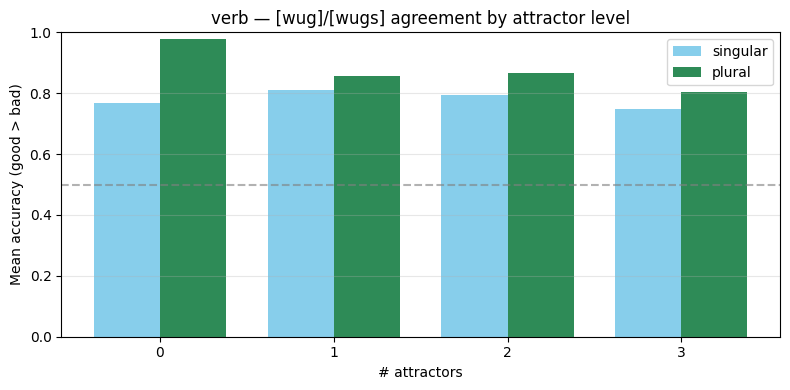

In [90]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

CSV_PATH   = "../nb/stimuli_gen/agreement_target_natural.csv"   # adjust path if needed
BATCH_SIZE = 16

# ==========================================================
# Load CSV -> flat good/bad lists + parallel metadata
#   each row carries a sg tuple and a pl tuple:
#     good_singular / bad_singular  -> meta number "sg"
#     good_plural   / bad_plural     -> meta number "pl"
# ==========================================================
df = pd.read_csv(CSV_PATH)

goods, bads, meta = [], [], []   # meta: (n_attractors, number, condition)
for _, r in df.iterrows():
    n_attr = int(r["attractors"])
    cond   = r["target_type"]            # "verb" throughout this CSV
    # singular tuple
    goods.append(r["good_singular"]); bads.append(r["bad_singular"])
    meta.append((n_attr, "sg", cond))
    # plural tuple
    goods.append(r["good_plural"]);   bads.append(r["bad_plural"])
    meta.append((n_attr, "pl", cond))

assert len(goods) == len(bads) == len(meta)
print(f"Loaded {len(df)} rows -> {len(goods)} good/bad pairs")

# ==========================================================
# Wrap in the same chat-style context
# ==========================================================
good_queries = [chat_template(lm, s, noimage=True, assistant=False) for s in goods]
bad_queries  = [chat_template(lm, s, noimage=True, assistant=False) for s in bads]

# ==========================================================
# Confirm a wug/wugs token id appears in EVERY tokenized query
# ==========================================================
tok = lm.tokenizer.tokenizer
def _ids(text):
    return tok(text, add_special_tokens=False).input_ids

wug_ids  = _ids(" [wug]")
wugs_ids = _ids(" [wugs]")
assert len(wug_ids) == 1 and len(wugs_ids) == 1, \
    f"[wug]/[wugs] are not single tokens (got {wug_ids}, {wugs_ids})."
wug_id, wugs_id = wug_ids[0], wugs_ids[0]

missing = [i for i, q in enumerate(good_queries + bad_queries)
           if wug_id not in _ids(q) and wugs_id not in _ids(q)]
# assert not missing, (f"{len(missing)} queries contain neither wug nor wugs; "
                     #f"first few idx: {missing[:5]}")
print(f"✓ all {len(good_queries) + len(bad_queries)} queries contain a novel token "
      f"(wug={wug_id}, wugs={wugs_id})")

# ==========================================================
# Batched scoring
# ==========================================================
def batched_sequence_score(lm, queries, batch_size=16):
    scores = []
    n = len(queries)
    for i in range(0, n, batch_size):
        batch = queries[i:i + batch_size]
        scores.extend(lm.sequence_score(batch))
        print(f"    scored {min(i + batch_size, n)}/{n}", end="\r")
    print()
    return torch.tensor(scores, dtype=torch.float32)

print("Scoring good queries...")
good_scores = batched_sequence_score(lm, good_queries, batch_size=BATCH_SIZE)
print("Scoring bad queries...")
bad_scores  = batched_sequence_score(lm, bad_queries,  batch_size=BATCH_SIZE)

# ==========================================================
# Per-sample diffs / accuracy
# ==========================================================
diffs = good_scores - bad_scores
acc_mask = (diffs > 0).float()

def acc_for(n_attr, number=None, cond=None):
    idx = [i for i, (na, nb, cd) in enumerate(meta)
           if na == n_attr
           and (number is None or nb == number)
           and (cond is None or cd == cond)]
    if not idx:
        return float("nan"), 0
    return acc_mask[torch.tensor(idx)].mean().item(), len(idx)

# ==========================================================
# Print results (per condition present in the CSV)
# ==========================================================
levels = sorted(df["attractors"].unique().tolist())
conds  = list(dict.fromkeys(m[2] for m in meta))   # preserve order, usually ["verb"]

print(f"\nN pairs: {len(goods)}  | overall acc={acc_mask.mean().item():.3f}")
for cd in conds:
    cond_idx = [i for i, m in enumerate(meta) if m[2] == cd]
    print(f"\n{cd}  (overall acc={acc_mask[torch.tensor(cond_idx)].mean().item():.3f}, "
          f"n={len(cond_idx)})")
    for na in levels:
        a_all, n_all = acc_for(na, None, cd)
        a_sg, _ = acc_for(na, "sg", cd)
        a_pl, _ = acc_for(na, "pl", cd)
        print(f"  {na} attractor(s): all={a_all:.3f}  sg={a_sg:.3f}  pl={a_pl:.3f}  (n={n_all})")

# ==========================================================
# Faceted plot: one row per condition, sg vs pl by attractor level
# ==========================================================
x = np.arange(len(levels))
w = 0.38
fig, axes = plt.subplots(len(conds), 1, figsize=(8, 4 * len(conds)),
                         sharey=True, squeeze=False)
axes = axes[:, 0]

for ax, cd in zip(axes, conds):
    sg = [acc_for(na, "sg", cd)[0] for na in levels]
    pl = [acc_for(na, "pl", cd)[0] for na in levels]
    ax.bar(x - w/2, sg, w, color="skyblue",  label="singular")
    ax.bar(x + w/2, pl, w, color="seagreen", label="plural")
    ax.axhline(0.5, ls="--", color="gray", alpha=0.6)
    ax.set_ylim(0, 1); ax.set_xticks(x); ax.set_xticklabels(levels)
    ax.set_ylabel("Mean accuracy (good > bad)")
    ax.set_title(f"{cd} — [wug]/[wugs] agreement by attractor level")
    ax.grid(axis="y", alpha=0.3); ax.legend()

axes[-1].set_xlabel("# attractors")
plt.tight_layout()
plt.show()

Counts (both sg & pl correct):
attractors    0    1    2    3
split                         
train       506  453  448  376
test        543  503  489  415

Accuracy (both correct):
attractors      0      1      2      3
split                                 
train       0.723  0.647  0.640  0.537
test        0.776  0.719  0.699  0.593


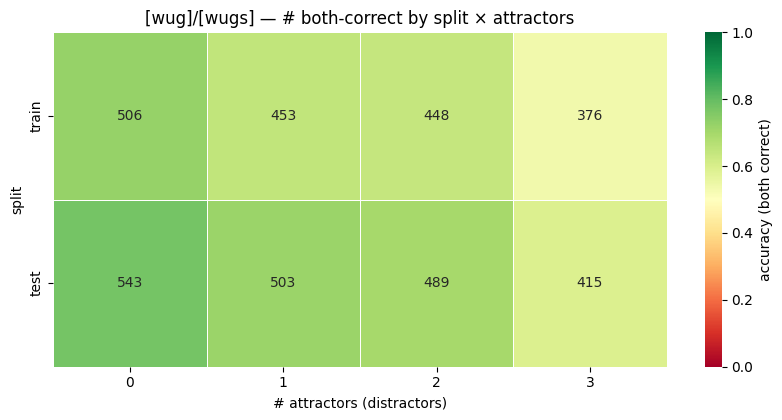

In [91]:
import seaborn as sns

# ==========================================================
# Per-row "both correct": sg entry at 2*i, pl entry at 2*i+1
# (goods/bads were appended sg-then-pl for each df row)
# ==========================================================
ac = acc_mask.cpu().numpy()
both_correct = (ac[0::2].astype(bool) & ac[1::2].astype(bool))   # len == len(df)
assert len(both_correct) == len(df)

res = df.copy()
res["both_correct"] = both_correct

# count (# both-correct) and accuracy (mean) per split x attractors
count = res.pivot_table(index="split", columns="attractors",
                        values="both_correct", aggfunc="sum", fill_value=0)
acc   = res.pivot_table(index="split", columns="attractors",
                        values="both_correct", aggfunc="mean", fill_value=0)

# keep a stable row order if both splits present
row_order = [s for s in ["train", "test"] if s in count.index]
count = count.reindex(row_order)
acc   = acc.reindex(row_order)

print("Counts (both sg & pl correct):"); print(count)
print("\nAccuracy (both correct):");      print(acc.round(3))

# ==========================================================
# Heatmap: color = accuracy, annotation = raw count correct
# ==========================================================
fig, ax = plt.subplots(figsize=(1.6 * count.shape[1] + 2, 1.4 * count.shape[0] + 1.5))
sns.heatmap(
    acc, ax=ax, annot=count, fmt="d",
    vmin=0, vmax=1, cmap="RdYlGn",
    cbar_kws={"label": "accuracy (both correct)"},
    linewidths=0.5, linecolor="white",
)
ax.set_title("[wug]/[wugs] — # both-correct by split × attractors")
ax.set_xlabel("# attractors (distractors)")
ax.set_ylabel("split")
plt.tight_layout()
plt.show()